This notebook contains some examples of figures created by the code in this repository.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import datetime
import scipy

# Time series analysis

A time series of the historical closing price of gold is taken from Yahoo Finance. The log daily returns are calculated and plotted as a histogram and compared to a fitted Normal distribution.

In [ ]:
from get_price_returns import download_financial_data, calculate_log_daily_returns, plot_daily_returns_hist

In [ ]:
ticker = 'GC=F'

start_date = datetime.datetime(2019, 1, 1)
end_date = datetime.datetime(2026, 1, 1)

closing_prices = download_financial_data(ticker, start_date, end_date)

In [ ]:
closing_prices.describe()

In [ ]:
log_daily_returns = calculate_log_daily_returns(closing_prices)
log_daily_returns.describe()

In [ ]:
plot_daily_returns_hist(ticker, log_daily_returns)

# Monte-Carlo mean-variance portfolio optimisation

Generate a sample of random portfolios for a given asset universe and plot the efficient frontier. The global minimum variance and tangency portfolios are labelled.

In [ ]:
import markowitz_model as mm

In [ ]:
n_trading_days = 252    # trading days in a year
n_portfolios = 2000    # number of random portfolios to generate

assets = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN']  # asset universe
start_date = datetime.date(2019, 1, 1)
end_date = datetime.date.today()
risk_free_rate = 0.05

In [ ]:
#dataset = mm.download_data(assets, start_date, end_date)
#dataset.to_csv("testing_dataset.csv")
dataset = pd.read_csv("testing_dataset.csv", index_col=0)
mm.show_data(dataset, 'Date', 'Closing price')

In [ ]:
log_daily_returns = mm.calculate_returns(dataset)
mm.show_statistics(log_daily_returns, n_trading_days)

In [ ]:
mm.show_data(log_daily_returns, 'Date', 'Log Return')

Expected return and volatility with an **equal-weighted** portfolio

In [ ]:
weights = np.ones(len(assets)) / len(assets)
mu, sigma, S = mm.get_portfolio_statistics(weights, log_daily_returns, n_trading_days, risk_free_rate)
print("Expected return: ", np.round(mu, 2))
print("Expected volatility: ", np.round(sigma, 2))
print("Sharpe ratio: ", np.round(S, 2))

### Generate random portfolios and plot risk-return and Sharpe ratio:

Expected portfolio return
\begin{equation}
\mu = \boldsymbol{\omega}^{T}\boldsymbol{\mu}
\end{equation}

Expected portfolio volatility
\begin{equation}
\sigma = \sqrt{\boldsymbol{\sigma}^{T}\boldsymbol{\Sigma}\boldsymbol{\sigma}}
\end{equation}

Sharpe ratio
\begin{equation}
S = \frac{\mu - r}{\sigma}
\end{equation}

In [ ]:
mm.plot_portfolios(assets, log_daily_returns, n_portfolios, n_trading_days, risk_free_rate=0.03)

# Vasicek model

Price a zero-coupon bond using a Monte-Carlo simulation.

In [2]:
from vasicek_model import price_bond_monte_carlo, plot_interest_rate_paths

In [5]:
BUSINESS_DAYS = 252
YEARS = 3

In [17]:
%%time
bond_price, walks, time_grid = price_bond_monte_carlo(
            principal=1000, 
            r0=0.05, 
            kappa=0.08, 
            theta=0.0225, 
            sigma=0.03,
            T=YEARS,
            num_simulations=1000,
            num_time_steps=BUSINESS_DAYS*YEARS
            )
print('Bond price: $%.2f' % bond_price)

Bond price: $870.11
CPU times: user 54.2 ms, sys: 86.5 ms, total: 141 ms
Wall time: 139 ms


Note that the model permits negative interest rates:

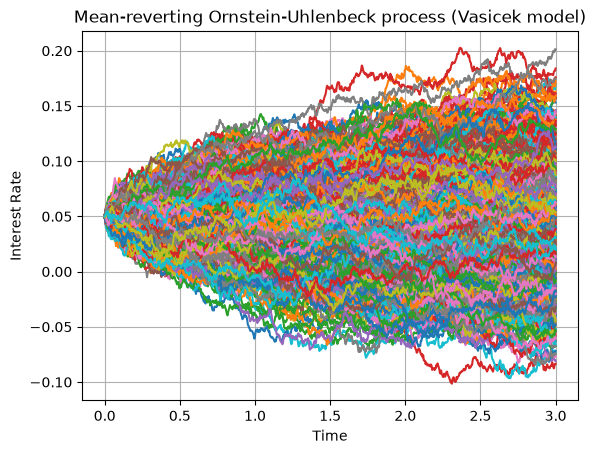

In [19]:
plot_interest_rate_paths(walks, time_grid)